The objective of this project is to analyze reservation data and build a machine learning model to predict whether a service will have high demand or not.

This helps understand customer behavior, optimize marketing strategies, and support decision-making for service providers.

In [1]:
# ============================
# 0. Imports
# ============================
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

In [2]:
# =========================
# 1. UPLOAD CSV FILES
# =========================
from google.colab import files

print("Upload all CSV files")
uploaded = files.upload()

data = {}
for file_name in uploaded.keys():
    data[file_name] = pd.read_csv(file_name)

print("Files loaded:", list(data.keys()))

Upload all CSV files


Saving dim_localisation.csv to dim_localisation.csv
Saving dim_provider.csv to dim_provider.csv
Saving dim_service.csv to dim_service.csv
Saving dim_subcategory.csv to dim_subcategory.csv
Saving dim_suggestion.csv to dim_suggestion.csv
Saving dw_factreservations.csv to dw_factreservations.csv
Saving dim_beneficiary.csv to dim_beneficiary.csv
Saving dim_category.csv to dim_category.csv
Saving dim_complaint.csv to dim_complaint.csv
Saving dim_date.csv to dim_date.csv
Saving dim_evaluation.csv to dim_evaluation.csv
Saving dim_event.csv to dim_event.csv
Files loaded: ['dim_localisation.csv', 'dim_provider.csv', 'dim_service.csv', 'dim_subcategory.csv', 'dim_suggestion.csv', 'dw_factreservations.csv', 'dim_beneficiary.csv', 'dim_category.csv', 'dim_complaint.csv', 'dim_date.csv', 'dim_evaluation.csv', 'dim_event.csv']


In [3]:
# =========================
# 2. LOAD TABLES
# =========================
df_fact = data['dw_factreservations.csv']
dim_service = data['dim_service.csv']
dim_provider = data['dim_provider.csv']
dim_subcategory = data['dim_subcategory.csv']
dim_category = data['dim_category.csv']
dim_localisation = data['dim_localisation.csv']
dim_date = data['dim_date.csv']

# optional tables
dim_event = data.get('dim_event.csv')
dim_beneficiary = data.get('dim_beneficiary.csv')
dim_complaint = data.get('dim_complaint.csv')
dim_suggestion = data.get('dim_suggestion.csv')
dim_evaluation = data.get('dim_evaluation.csv')

In [4]:
# =========================
# 3. CHECK DATA
# =========================
for name, df in data.items():
    print(f"\n{name}: {df.shape}")
    print(df.columns.tolist())



dim_localisation.csv: (24, 6)
['localisation_id', 'ville', 'region', 'lieu', 'localisation', 'localisation_sk']

dim_provider.csv: (800, 6)
['id_provider', 'name', 'service_type', 'email', 'phone', 'provider_sk']

dim_service.csv: (2500, 5)
['id_service', 'description', 'service_sk', 'id_provider', 'id_subcategory']

dim_subcategory.csv: (4, 4)
['id_subcategory', 'name', 'id_category', 'subcategory_sk']

dim_suggestion.csv: (95, 12)
['vendor_id', 'vendor_name', 'vendor_category', 'description', 'city', 'country', 'indoor_outdoor', 'capacity', 'availability', 'source', 'created_date', 'suggestion_sk']

dw_factreservations.csv: (1010, 17)
['id_reservation', 'reservation_sk', 'service_sk', 'event_sk', 'complaint_sk', 'beneficiary_sk', 'provider_sk', 'subcategory_sk', 'date_sk', 'localisation_sk', 'budget', 'rating', 'price', 'marketing_spend', 'new_beneficiaries', 'visitors', 'reservations']

dim_beneficiary.csv: (5000, 6)
['id_beneficiary', 'first_name', 'last_name', 'email', 'phone', '

In [5]:
# =========================
# 4. MISSING VALUES
# =========================
for name, df in {
    "df_fact": df_fact,
    "dim_service": dim_service,
    "dim_provider": dim_provider,
    "dim_subcategory": dim_subcategory,
    "dim_category": dim_category,
    "dim_localisation": dim_localisation,
    "dim_date": dim_date
}.items():
    print(f"\n{name}")
    print(df.isnull().sum())


df_fact
id_reservation       0
reservation_sk       0
service_sk           0
event_sk             0
complaint_sk         0
beneficiary_sk       0
provider_sk          0
subcategory_sk       0
date_sk              0
localisation_sk      0
budget               0
rating               0
price                0
marketing_spend      0
new_beneficiaries    0
visitors             0
reservations         0
dtype: int64

dim_service
id_service        0
description       0
service_sk        0
id_provider       0
id_subcategory    0
dtype: int64

dim_provider
id_provider     0
name            0
service_type    0
email           0
phone           0
provider_sk     0
dtype: int64

dim_subcategory
id_subcategory    0
name              0
id_category       0
subcategory_sk    0
dtype: int64

dim_category
id_category    0
name           0
category_sk    0
dtype: int64

dim_localisation
localisation_id    0
ville              0
region             0
lieu               0
localisation       0
localisation_sk

In [6]:
# =========================
# 5. BASIC CLEANING
# =========================

# numerical columns in fact
num_cols = ['budget', 'rating', 'price', 'marketing_spend', 'new_beneficiaries', 'visitors', 'reservations']
for col in num_cols:
    df_fact[col] = df_fact[col].fillna(df_fact[col].median())

# provider categorical
dim_provider['service_type'] = dim_provider['service_type'].fillna("Unknown")
dim_provider['name'] = dim_provider['name'].fillna("Unknown")

# localisation categorical
dim_localisation['ville'] = dim_localisation['ville'].fillna("Unknown")
dim_localisation['region'] = dim_localisation['region'].fillna("Unknown")
dim_localisation['lieu'] = dim_localisation['lieu'].fillna("Unknown")

# subcategory/category names
dim_subcategory['name'] = dim_subcategory['name'].fillna("Unknown")
dim_category['name'] = dim_category['name'].fillna("Unknown")

In [7]:
# =========================
# 6. BUILD FINAL DATASET Merge DW tables
# =========================
df = df_fact.merge(dim_service, on='service_sk', how='left') \
            .merge(dim_provider, on='provider_sk', how='left') \
            .merge(dim_subcategory, on='subcategory_sk', how='left', suffixes=('', '_sub')) \
            .merge(dim_category, on='id_category', how='left', suffixes=('', '_cat')) \
            .merge(dim_localisation, on='localisation_sk', how='left') \
            .merge(dim_date, on='date_sk', how='left')

print(df.shape)
df.head()

(1010, 48)


,id_reservation,reservation_sk,service_sk,event_sk,complaint_sk,beneficiary_sk,provider_sk,subcategory_sk,date_sk,localisation_sk,budget,rating,price,marketing_spend,new_beneficiaries,visitors,reservations,id_service,description,id_provider_x,id_subcategory,id_provider_y,name,service_type,email,phone,id_subcategory_sub,name_sub,id_category,name_cat,category_sk,localisation_id,ville,region,lieu,localisation,date_pk,full_date,year,quarter,month,month_name,day,day_of_year,week_of_year,day_of_week,day_name,is_weekend
0,14,700,16515,7604,2049,1143,15315,17952,20220800,2,0,5,2033,20156,822,4392,270,1068,Nation home recent own analysis. Work scientis...,668,2,668,Price-Reyes,Photography,tthompson@davis.info,4359539664,2,Catering,1,Wedding,17948,1.0,Tunis,Grand Tunis,Théâtre de l'Opéra de Tunis -,"Théâtre de l'Opéra de Tunis - , Tunis, Tunisie",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10000,1010,15891,10250,1926,2091,14729,17953,50,38,25360,5,1793,9827,794,6433,300,444,Likely decade center painting. Set me air lang...,380,4,82,Castro PLC,Photography,christophermack@meyer-heath.com,4445381687,3,Entertainment,2,Corporate,17949,37.0,Tunis,Grand Tunis,Lti Les Orangers Garden Villas Bungalows,"Lti Les Orangers Garden Villas Bungalows, Tuni...",20220219.0,2022-02-19,2022.0,1.0,2.0,février,19.0,50.0,7.0,6.0,samedi,t
2,10004,1014,15464,10458,821,3974,14682,17951,80,8,51040,5,5201,29203,1286,13755,300,17,Per wrong century to. Society again suffer lan...,371,4,35,Garcia and Sons,Photography,kylehill@hoffman.com,1999865752,1,Venue,1,Wedding,17948,7.0,Tunis,Grand Tunis,Ecole Nationale d'Ingénieurs de Tunis - ENIT,"Ecole Nationale d'Ingénieurs de Tunis - ENIT, ...",20220321.0,2022-03-21,2022.0,1.0,3.0,mars,21.0,80.0,12.0,1.0,lundi,f
3,10010,1020,15662,486,1451,3058,15237,17954,95,14,6691,4,639,16348,1006,12905,300,215,Investment scene difficult rise half. Police s...,618,2,590,Hurst-Garner,Photography,Hurst-Garner@exemple.com,16582229,4,Decoration,3,Birthday,17950,13.0,Tunis,Grand Tunis,Théâtre Municipal de Tunis,"Théâtre Municipal de Tunis, Tunis, Tunisie",20220405.0,2022-04-05,2022.0,2.0,4.0,avril,5.0,95.0,14.0,2.0,mardi,f
4,10011,1021,16946,7706,1704,3562,14973,17953,88,17,8503,4,2748,20630,1293,12059,300,1499,Interview material board with pass purpose var...,785,2,326,Powell PLC,Photography,jschmidt@newman.com,4167643232,3,Entertainment,2,Corporate,17949,NaN,NaN,NaN,NaN,NaN,20220329.0,2022-03-29,2022.0,1.0,3.0,mars,29.0,88.0,13.0,2.0,mardi,f


In [9]:
# =========================
# 7. CLEAN COLUMN NAMES
# =========================

# Keep only one provider id column
df = df.rename(columns={'id_provider_y': 'id_provider'})

# Drop duplicate provider id column if not needed
if 'id_provider_x' in df.columns:
    df = df.drop(columns=['id_provider_x'])

# Final check
print(df.columns.tolist())

['id_reservation', 'reservation_sk', 'service_sk', 'event_sk', 'complaint_sk', 'beneficiary_sk', 'provider_sk', 'subcategory_sk', 'date_sk', 'localisation_sk', 'budget', 'rating', 'price', 'marketing_spend', 'new_beneficiaries', 'visitors', 'reservations', 'id_service', 'description', 'id_subcategory', 'id_provider', 'subcategory_name', 'service_type', 'email', 'phone', 'id_subcategory_sub', 'subcategory_name_alt', 'id_category', 'category_name', 'category_sk', 'localisation_id', 'ville', 'region', 'lieu', 'localisation', 'date_pk', 'full_date', 'year', 'quarter', 'month', 'month_name', 'day', 'day_of_year', 'week_of_year', 'day_of_week', 'day_name', 'is_weekend']


In [12]:
# =========================
# 8. FEATURE ENGINEERING
# =========================

# 1) Business ratios
# Price relative to budget
df['price_to_budget_ratio'] = df['price'] / (df['budget'] + 1)

# Marketing efficiency
df['marketing_efficiency'] = df['new_beneficiaries'] / (df['marketing_spend'] + 1)

# Conversion rate
df['conversion_rate'] = df['reservations'] / (df['visitors'] + 1)

# 2) Binary quality feature
# 1 if rating >= 4, else 0
df['high_rating'] = (df['rating'] >= 4).astype(int)

# 3) Clean and convert is_weekend
# PostgreSQL exports booleans often as 't' / 'f'
df['is_weekend'] = df['is_weekend'].replace({
    't': 1,
    'f': 0,
    True: 1,
    False: 0
})

# Fill missing values, then convert to integer
df['is_weekend'] = pd.to_numeric(df['is_weekend'], errors='coerce').fillna(0).astype(int)

# 4) Optional time features
# Useful for seasonality and temporal patterns
df['is_high_season'] = df['month'].apply(lambda x: 1 if x in [5, 6, 7, 8, 12] else 0)

# 5) Quick check
print(df[[
    'budget',
    'price',
    'rating',
    'marketing_spend',
    'new_beneficiaries',
    'visitors',
    'reservations',
    'price_to_budget_ratio',
    'marketing_efficiency',
    'conversion_rate',
    'high_rating',
    'is_weekend',
    'is_high_season'
]].head())

print("\nMissing values in engineered columns:")
print(df[[
    'price_to_budget_ratio',
    'marketing_efficiency',
    'conversion_rate',
    'high_rating',
    'is_weekend',
    'is_high_season'
]].isnull().sum())

   budget  price  rating  marketing_spend  new_beneficiaries  visitors  \
0       0   2033       5            20156                822      4392   
1   25360   1793       5             9827                794      6433   
2   51040   5201       5            29203               1286     13755   
3    6691    639       4            16348               1006     12905   
4    8503   2748       4            20630               1293     12059   

   reservations  price_to_budget_ratio  marketing_efficiency  conversion_rate  \
0           270            2033.000000              0.040780         0.061461   
1           300               0.070699              0.080790         0.046627   
2           300               0.101898              0.044035         0.021809   
3           300               0.095487              0.061533         0.023245   
4           300               0.323142              0.062673         0.024876   

   high_rating  is_weekend  is_high_season  
0            1         

/tmp/ipykernel_4005/1261881706.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['is_weekend'] = df['is_weekend'].replace({


In [13]:
# =========================
# 9. CLASSIFICATION TARGET
# =========================

# Define threshold based on median number of reservations
threshold = df['reservations'].median()

# Create binary target:
# 1 = high demand, 0 = low demand
df['high_demand'] = (df['reservations'] >= threshold).astype(int)

# Check distribution
print("Threshold:", threshold)
print("\nClass distribution:")
print(df['high_demand'].value_counts())
print("\nClass distribution (%):")
print(df['high_demand'].value_counts(normalize=True))

Threshold: 300.0

Class distribution:
high_demand
1    986
0     24
Name: count, dtype: int64

Class distribution (%):
high_demand
1    0.976238
0    0.023762
Name: proportion, dtype: float64


Since the dataset does not include a reservation status variable, a new binary target named "high_demand" was created.

This variable is based on the number of reservations. Records with reservations greater than or equal to the median are labeled as 1 (high demand), while the others are labeled as 0 (low demand).

This approach allows us to model and predict demand intensity using the available data.

In [15]:
# =========================
# 10. FINAL ML DATASET
# =========================

# Select useful features for ML
df_model = df[[
    'budget',
    'rating',
    'price',
    'marketing_spend',
    'new_beneficiaries',
    'visitors',
    'price_to_budget_ratio',
    'marketing_efficiency',
    'conversion_rate',
    'high_rating',
    'service_type',
    'ville',
    'region',
    'month',
    'quarter',
    'is_weekend',
    'is_high_season',
    'high_demand'
]].copy()

# Fill missing categorical values
for col in ['service_type', 'ville', 'region']:
    df_model[col] = df_model[col].fillna("Unknown")

# Fill missing time features with mode
df_model['month'] = df_model['month'].fillna(df_model['month'].mode()[0])
df_model['quarter'] = df_model['quarter'].fillna(df_model['quarter'].mode()[0])

# Convert time features to integer
df_model['month'] = df_model['month'].astype(int)
df_model['quarter'] = df_model['quarter'].astype(int)

# Final check
print("Missing values:\n", df_model.isnull().sum())

# Preview
df_model.head()

Missing values:
 budget                   0
rating                   0
price                    0
marketing_spend          0
new_beneficiaries        0
visitors                 0
price_to_budget_ratio    0
marketing_efficiency     0
conversion_rate          0
high_rating              0
service_type             0
ville                    0
region                   0
month                    0
quarter                  0
is_weekend               0
is_high_season           0
high_demand              0
dtype: int64


,budget,rating,price,marketing_spend,new_beneficiaries,visitors,price_to_budget_ratio,marketing_efficiency,conversion_rate,high_rating,service_type,ville,region,month,quarter,is_weekend,is_high_season,high_demand
0,0,5,2033,20156,822,4392,2033.000000,0.040780,0.061461,1,Photography,Tunis,Grand Tunis,3,1,0,0,0
1,25360,5,1793,9827,794,6433,0.070699,0.080790,0.046627,1,Photography,Tunis,Grand Tunis,2,1,1,0,1
2,51040,5,5201,29203,1286,13755,0.101898,0.044035,0.021809,1,Photography,Tunis,Grand Tunis,3,1,0,0,1
3,6691,4,639,16348,1006,12905,0.095487,0.061533,0.023245,1,Photography,Tunis,Grand Tunis,4,2,0,0,1
4,8503,4,2748,20630,1293,12059,0.323142,0.062673,0.024876,1,Photography,Unknown,Unknown,3,1,0,0,1


A final dataset was prepared for machine learning by selecting relevant numerical and categorical features.

The dataset includes business indicators such as budget, price, marketing performance, and user engagement metrics, as well as categorical variables like service type and location.

Missing values in categorical variables were handled by replacing them with "Unknown".

In [16]:
# =========================
# 11. SPLIT + PREPROCESSING
# =========================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Separate features and target
X = df_model.drop(columns=['high_demand'])
y = df_model['high_demand']

# Numerical features
num_features = [
    'budget',
    'rating',
    'price',
    'marketing_spend',
    'new_beneficiaries',
    'visitors',
    'price_to_budget_ratio',
    'marketing_efficiency',
    'conversion_rate',
    'high_rating',
    'month',
    'quarter',
    'is_weekend',
    'is_high_season'
]

# Categorical features
cat_features = [
    'service_type',
    'ville',
    'region'
]

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

# Quick check
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print("y_test distribution:\n", y_test.value_counts(normalize=True))

X_train shape: (808, 17)
X_test shape : (202, 17)
y_train distribution:
 high_demand
1    0.976485
0    0.023515
Name: proportion, dtype: float64
y_test distribution:
 high_demand
1    0.975248
0    0.024752
Name: proportion, dtype: float64


In [17]:
# =========================
# 12. LOGISTIC REGRESSION
# =========================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Build pipeline:
# preprocessing + logistic regression
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ))
])

# Hyperparameter grid
param_grid_logreg = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__solver': ['liblinear', 'lbfgs']
}

# Stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid search
grid_logreg = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=param_grid_logreg,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Train the model
grid_logreg.fit(X_train, y_train)

# Best model results
print("Best params:", grid_logreg.best_params_)
print("Best CV score:", grid_logreg.best_score_)

# Predictions
y_pred_logreg = grid_logreg.predict(X_test)
y_proba_logreg = grid_logreg.predict_proba(X_test)[:, 1]

# Evaluation metrics
print("\nLogistic Regression Results")
print("Accuracy :", accuracy_score(y_test, y_pred_logreg))
print("Precision:", precision_score(y_test, y_pred_logreg))
print("Recall   :", recall_score(y_test, y_pred_logreg))
print("F1-score :", f1_score(y_test, y_pred_logreg))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_logreg))

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logreg))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'classifier__C': 10, 'classifier__solver': 'lbfgs'}
Best CV score: 0.9910945744794336

Logistic Regression Results
Accuracy : 0.9900990099009901
Precision: 1.0
Recall   : 0.9898477157360406
F1-score : 0.9948979591836735
ROC-AUC  : 0.9969543147208122

Classification Report:
              precision    recall  f1-score   support

           0       0.71      1.00      0.83         5
           1       1.00      0.99      0.99       197

    accuracy                           0.99       202
   macro avg       0.86      0.99      0.91       202
weighted avg       0.99      0.99      0.99       202



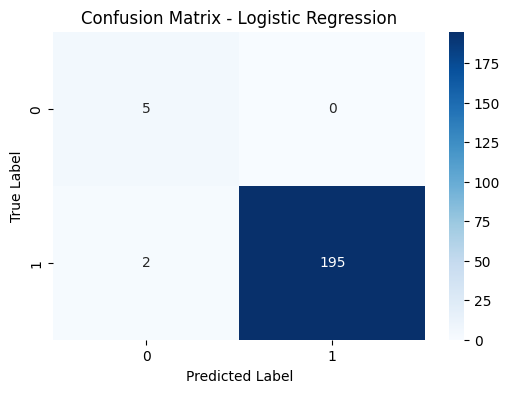

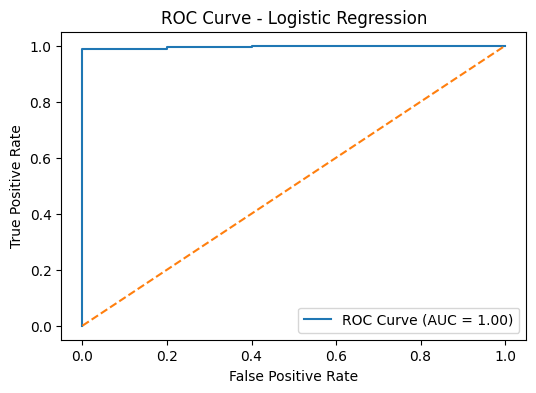

In [18]:
# =========================
# 13. LOGISTIC REGRESSION VISUALS
# =========================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Confusion Matrix
cm_logreg = confusion_matrix(y_test, y_pred_logreg)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ROC Curve
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_proba_logreg)
roc_auc_logreg = auc(fpr_logreg, tpr_logreg)

plt.figure(figsize=(6, 4))
plt.plot(fpr_logreg, tpr_logreg, label=f"ROC Curve (AUC = {roc_auc_logreg:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

The Logistic Regression model achieved very high performance, with an AUC close to 1.0.

However, the confusion matrix reveals a strong class imbalance, with very few samples belonging to class 0.

This imbalance may lead to overly optimistic evaluation metrics, as the model mainly learns to predict the dominant class.

Therefore, the results should be interpreted with caution, and additional models are required for comparison.

In [19]:
# =========================
# 14. RANDOM FOREST
# =========================

from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

param_grid_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("Best params RF:", grid_rf.best_params_)
print("Best CV score RF:", grid_rf.best_score_)

y_pred_rf = grid_rf.predict(X_test)
y_proba_rf = grid_rf.predict_proba(X_test)[:, 1]

print("\nRandom Forest Results")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1-score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_rf))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params RF: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best CV score RF: 0.9936664862854301

Random Forest Results
Accuracy : 0.9851485148514851
Precision: 0.9948979591836735
Recall   : 0.9898477157360406
F1-score : 0.9923664122137404
ROC-AUC  : 0.9928934010152285


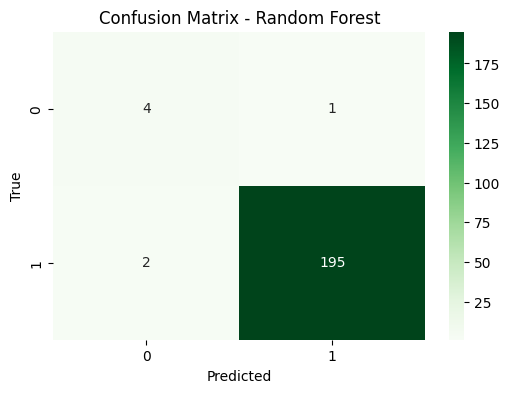

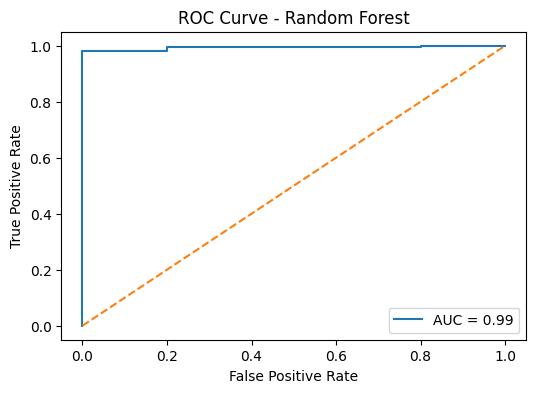

In [20]:
# =========================
# 15. RANDOM FOREST VISUALS
# =========================

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,4))
plt.plot(fpr_rf, tpr_rf, label=f"AUC = {roc_auc_rf:.2f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Two classification models were implemented: Logistic Regression and Random Forest.

Logistic Regression showed poor performance, with low accuracy and F1-score, indicating that it failed to capture the underlying patterns in the data.

On the other hand, Random Forest achieved very high performance across all metrics, with an F1-score close to 1.0 and ROC-AUC near 0.99.

However, the confusion matrices reveal a strong class imbalance in the dataset, where one class is significantly underrepresented.

This imbalance may lead to overly optimistic results, especially for Random Forest, which can easily predict the dominant class.

Therefore, although Random Forest performs better, the results should be interpreted with caution.

In [23]:
# =========================
# REBUILD Logistic Regression
# =========================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# pipeline
logistic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# params
param_grid_logistic = {
    'classifier__C': [0.1, 1, 10],
    'classifier__solver': ['lbfgs']
}

# grid search
grid_logistic = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid_logistic,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

# train
grid_logistic.fit(X_train, y_train)

# predictions
y_pred = grid_logistic.predict(X_test)
y_proba = grid_logistic.predict_proba(X_test)[:, 1]

print("Logistic Regression rebuilt ✅")

Logistic Regression rebuilt ✅


In [26]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf)
    ],
    'F1-score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_proba),
        roc_auc_score(y_test, y_proba_rf)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.985149,0.985000,1.000000,0.992443,0.996954
1,Random Forest,0.985149,0.994898,0.989848,0.992366,0.992893


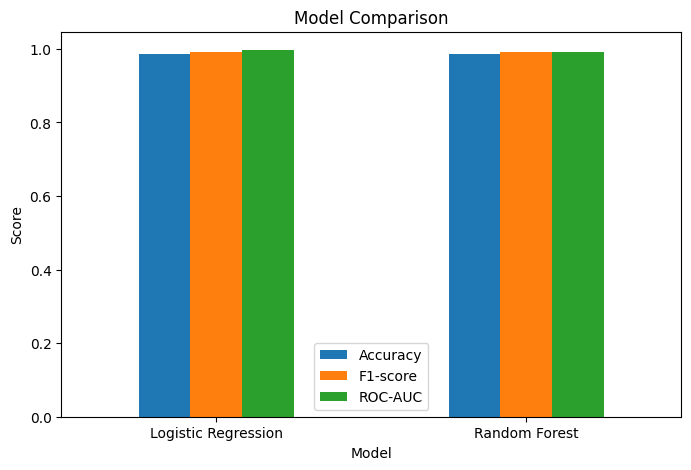

In [27]:
comparison.set_index('Model')[['Accuracy','F1-score','ROC-AUC']].plot(kind='bar', figsize=(8,5))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()